<a href="https://colab.research.google.com/github/yewonhn/My-AI-Lab/blob/main/6%EC%A3%BC%EC%B0%A8/06_Abalone_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/abalone.csv")
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


###성별 One-Hot-Encoding

In [3]:
df = pd.get_dummies(df, columns=['Sex'])

In [8]:
df

,id,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Sex_F,Sex_I,Sex_M
0,0,0,0,0,0,0,0,0,15,0,0,1
1,1,0,0,0,0,0,0,0,7,0,0,1
2,2,0,0,0,0,0,0,0,9,1,0,0
3,3,0,0,0,0,0,0,0,10,0,0,1
4,4,0,0,0,0,0,0,0,7,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4172,4172,0,0,0,0,0,0,0,11,1,0,0
4173,4173,0,0,0,0,0,0,0,10,0,0,1
4174,4174,0,0,0,1,0,0,0,9,0,0,1
4175,4175,0,0,0,1,0,0,0,10,1,0,0


In [4]:
X = df.drop('Rings', axis=1)
y = df['Rings']

#####결측치 확인 : 없음!

In [5]:
df.isnull().sum()

,0
id,0
Length,0
Diameter,0
Height,0
Whole_weight,0
Shucked_weight,0
Viscera_weight,0
Shell_weight,0
Rings,0
Sex_F,0


####스케일링
이유 : 전복데이터의 길이와 무게는 단위와 숫자 크기가 전부 제각각임. 숫자가 큰 특성이 더 큰 영향을 주는 것을 방지하려고 모든 데이터를 비슷한 범위로 맞추기

In [6]:
from sklearn.model_selection import train_test_split

# 1. 훈련, 테스트 데이터 나누기
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. 스케일링 (train 기준으로?)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
df

,id,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Sex_F,Sex_I,Sex_M
0,0,0,0,0,0,0,0,0,15,0,0,1
1,1,0,0,0,0,0,0,0,7,0,0,1
2,2,0,0,0,0,0,0,0,9,1,0,0
3,3,0,0,0,0,0,0,0,10,0,0,1
4,4,0,0,0,0,0,0,0,7,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4172,4172,0,0,0,0,0,0,0,11,1,0,0
4173,4173,0,0,0,0,0,0,0,10,0,0,1
4174,4174,0,0,0,1,0,0,0,9,0,0,1
4175,4175,0,0,0,1,0,0,0,10,1,0,0


####딥러닝 모델 생성
학습 데이터로 학습 시키기

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 모델 생성
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),   # 입력층과 첫 번 째 중간 레이어
    Dense(32, activation='relu'),  # 중간 레이어. 중간층
    Dense(1)  # 회귀 → 출력층 노드가 1개
])

# 컴파일
model.compile(
    optimizer='adam',
    loss='mse',      # 회귀니까 mse
    metrics=['mae']  # 오차 확인용
)

# 50번 학습 시킴
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 61.8418 - mae: 6.9106 - val_loss: 18.0851 - val_mae: 3.3259
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 12.6809 - mae: 2.5462 - val_loss: 6.6976 - val_mae: 1.8670
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.3227 - mae: 1.7902 - val_loss: 5.2002 - val_mae: 1.6397
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2941 - mae: 1.7196 - val_loss: 4.9067 - val_mae: 1.5424
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.8656 - mae: 1.6726 - val_loss: 4.5903 - val_mae: 1.5301
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.6211 - mae: 1.6521 - val_loss: 4.5391 - val_mae: 1.4906
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.2589 - mae: 1.6107 - val_loss: 4.4648 - val_mae: 1.5414
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.1420 - mae: 1.6118 - val_loss: 4.3352 - val_mae: 1.4791
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.0669 - ma

###평가
이제는 테스트 데이터를 넣어 모델을 평가

MSE가 실제 실력(실제와 예측의 차)
LOSS는 학습 점수(0에 가까울 수록 최적화)

In [8]:
loss, mae = model.evaluate(X_test, y_test)
print("MAE:", mae)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.3499 - mae: 1.4917
MAE: 1.4916753768920898


pred : 모델이 예측한 값

In [14]:
pred = model.predict(X_test)

# 모델의 예측값(답안지) 처음 5개
print("모델 예측값(pred):", pred[:5].flatten()) # flatten()은 보기 편하게 옆으로 나열해주는 함수

# 실제 정답(정답지) 처음 5개
print("실제 정답(y_test):", y_test[:5].values) # values를 붙이면 인덱스 없이 숫자만 나옴

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
모델 예측값(pred): [12.139712  9.59405  15.252303 10.413247 11.649453]
실제 정답(y_test): [ 9  8 16  9 14]


#### 예측값과 실제값을 비교, 그래프로 보기

x축 : 실제 나이(y_test)  <br>
y축 : 예측 나이(pred)

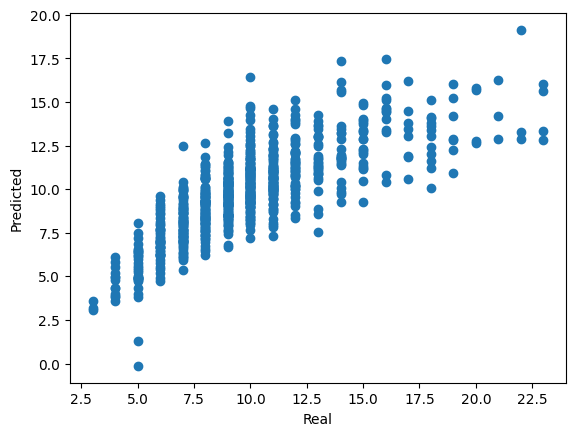

In [10]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred)
plt.xlabel("Real")
plt.ylabel("Predicted")
plt.show()